In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('../data/raw/master_data.csv')

In [3]:
# ---- Basic Dataset info----
df.head() # print first 5 rows
df.shape # rows & columns
df.info() # columns null values data types
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               10000 non-null  object 
 1   customer_id            10000 non-null  object 
 2   restaurant_id          10000 non-null  object 
 3   partner_id             10000 non-null  object 
 4   order_date             10000 non-null  object 
 5   order_value            10000 non-null  int64  
 6   company_commission     10000 non-null  float64
 7   delivery_fee           10000 non-null  int64  
 8   delivery_time_minutes  9196 non-null   float64
 9   order_status           10000 non-null  object 
 10  customer_rating        9196 non-null   float64
 11  customer_name          10000 non-null  object 
 12  customer_city          10000 non-null  object 
 13  age                    10000 non-null  int64  
 14  gender                 10000 non-null  object 
 15  sig

order_id                   0
customer_id                0
restaurant_id              0
partner_id                 0
order_date                 0
order_value                0
company_commission         0
delivery_fee               0
delivery_time_minutes    804
order_status               0
customer_rating          804
customer_name              0
customer_city              0
age                        0
gender                     0
signup_date                0
restaurant_name            0
restaurant_city            0
cuisine                    0
rating                     0
partner_since              0
partner_name               0
partner_city               0
Vehicle_Types              0
Experience                 0
Joining_date               0
payment_id                 0
payment_method             0
payment_status             0
payment_amount             0
payment_date               0
Month                      0
Weekday                    0
Month_Name                 0
Order_Size    

In [4]:
df['order_status'].value_counts()

order_status
Delivered    9196
Cancelled     804
Name: count, dtype: int64

In [5]:
# Drop ID and name columns
df = df.drop(columns=['order_id', 'customer_id', 'restaurant_id', 'partner_id', 'payment_id', 'customer_name', 'restaurant_name', 'partner_name' , 'customer_rating' , 'delivery_time_minutes' , 'payment_status'])

In [6]:
df.shape

(10000, 25)

In [7]:
# ---- Features and Targets
X = df.drop(columns=['order_status'])
y = df["order_status"]

In [8]:
print(X.shape)
print(y.shape)

(10000, 24)
(10000,)


In [9]:
# ---- Handle Missing Values ----
numeric_cols = X.select_dtypes(include=["int64" , "float64"]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
X[numeric_cols].isnull().sum()

categorical_cols = X.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])


In [10]:
X.isnull().sum()

order_date            0
order_value           0
company_commission    0
delivery_fee          0
customer_city         0
age                   0
gender                0
signup_date           0
restaurant_city       0
cuisine               0
rating                0
partner_since         0
partner_city          0
Vehicle_Types         0
Experience            0
Joining_date          0
payment_method        0
payment_amount        0
payment_date          0
Month                 0
Weekday               0
Month_Name            0
Order_Size            0
Is_Weekend            0
dtype: int64

In [11]:
y = y.str.strip()

In [12]:
y = y.map({
    "Delivered":0,
    "Cancelled":1
})

In [13]:
print(y.unique())
print(y.isnull().sum())

[0 1]
0


In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

In [16]:
print(X_train.shape)
print(X_test.shape)

(8000, 2235)
(2000, 2235)


Logistic Regresion

In [17]:
log_reg = LogisticRegression(max_iter=1000 , random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
# ---- Evaluating Logistic Regression Model ----
log_reg_pred = log_reg.predict(X_test)

In [19]:
# ---- Metrics ----
print(f"Accuracy : {accuracy_score(y_test, log_reg_pred)}")
print(f"Precision : {precision_score(y_test, log_reg_pred)}")
print(f"Recall : {recall_score(y_test, log_reg_pred)}")
print(f"F1-Score : {f1_score(y_test, log_reg_pred)}")
print(f"confusion_matrix")
print(confusion_matrix(y_test , log_reg_pred))
print(f"Classification Report")
print(classification_report(y_test , log_reg_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
confusion_matrix
[[1839    0]
 [   0  161]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1839
           1       1.00      1.00      1.00       161

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



decison tree

In [20]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
dt_pred = dt.predict(X_test)

In [22]:
print(f"Accuracy : {accuracy_score(y_test, dt_pred)}")
print(f"Precision : {precision_score(y_test,dt_pred)}")
print(f"Recall : {recall_score(y_test, dt_pred)}")
print(f"F1-Score : {f1_score(y_test, dt_pred)}")
print("Classification Report")
print(classification_report(y_test , dt_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1839
           1       1.00      1.00      1.00       161

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
rf_pred = rf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, rf_pred)}")
print(f"Precision : {precision_score(y_test,rf_pred)}")
print(f"Recall : {recall_score(y_test, rf_pred)}")
print(f"F1-Score : {f1_score(y_test, rf_pred)}")
print("Classification Report")
print(classification_report(y_test , rf_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1839
           1       1.00      1.00      1.00       161

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Model Comparison

In [25]:
Model_Comparison = pd.DataFrame({
    "Model" : ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy" : [accuracy_score(y_test, log_reg_pred), accuracy_score(y_test, dt_pred), accuracy_score(y_test, rf_pred)],
    "Precision" : [precision_score(y_test, log_reg_pred), precision_score(y_test, dt_pred), precision_score(y_test, rf_pred)],
    "Recall" : [recall_score(y_test, log_reg_pred), recall_score(y_test, dt_pred), recall_score(y_test, rf_pred)],
    "F1-Score" : [f1_score(y_test, log_reg_pred), f1_score(y_test, dt_pred), f1_score(y_test, rf_pred)]
})
print(Model_Comparison)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0
2        Random Forest       1.0        1.0     1.0       1.0


In [26]:
#--- Feature Importance from Random Forest Model ----
importance = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

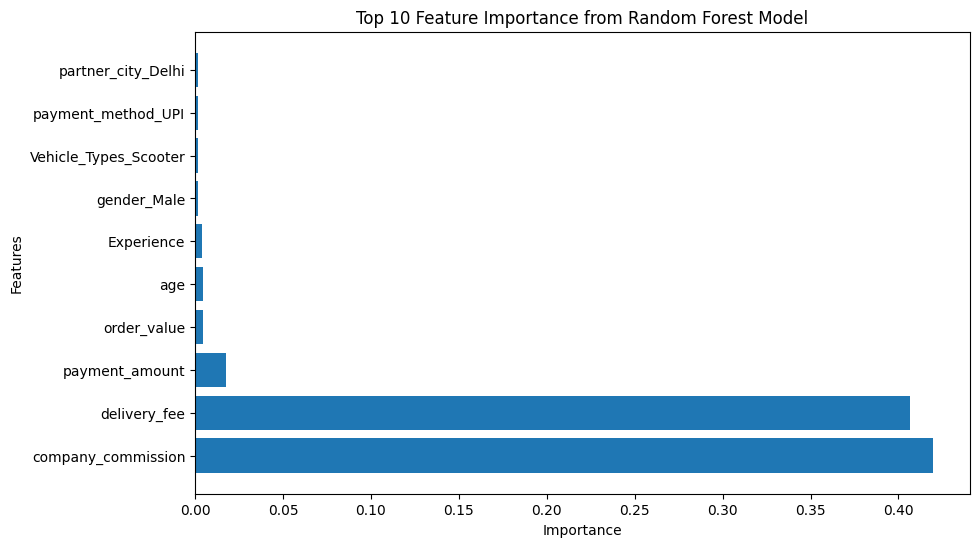

In [27]:
top_features = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features["Features"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance from Random Forest Model")
plt.show()

## BUSINESS INSIGHTS
- Compared Logistic Regression , Decision Tree and Random Forest Models for predicting order cancellation
- Feature Importance Analysis Identifying Key Factors that Influencing order cancellation
- These Insights can can help food delivery platform proactively High Risk Orders and reduce risk cancellation

In [29]:
print(X.columns)

Index(['order_value', 'company_commission', 'delivery_fee', 'age',
       'Experience', 'payment_amount', 'Is_Weekend', 'order_date_2024-06-25',
       'order_date_2024-06-26', 'order_date_2024-06-27',
       ...
       'Month_Name_February', 'Month_Name_January', 'Month_Name_July',
       'Month_Name_June', 'Month_Name_March', 'Month_Name_May',
       'Month_Name_November', 'Month_Name_October', 'Month_Name_September',
       'Order_Size_Low'],
      dtype='object', length=2235)


## Model Comparison

Three classification algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

All three models achieved nearly identical performance on the synthetic dataset.

## Project Limitation

This project uses a synthetically generated dataset created for learning purposes.

During model evaluation, all three algorithms achieved almost identical performance because several business attributes are highly correlated with the target variable.

In a real-world production system, additional historical behavioral features and naturally occurring cancellation patterns would be required to build a more robust predictive model.

## Business Recommendations

Although the dataset is synthetic, the analysis suggests several operational improvements:

• Monitor high-value orders more carefully.
• Encourage digital payment methods.
• Improve restaurant service quality.
• Assign experienced delivery partners to complex orders.
• Track cancellation trends across cities and restaurants.

In [31]:
import joblib

joblib.dump(rf, "food_delivery_cancellation_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
